<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/fabiobento/dnn-course-2026-1/blob/main/C1_M4_Lab_2_debugging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

# Depuração, Inspeção e Modularização de Modelos

Até agora, você se concentrou em construir e treinar modelos.
Mas, no mundo real, a sua primeira tentativa em um modelo raramente funciona perfeitamente.
Muitas vezes, você encontrará mensagens de erro enigmáticas sobre formatos incompatíveis de tensores (*mismatched tensor shapes*), ou pior, o seu modelo será executado sem erros, mas não conseguirá produzir resultados significativos.

É aqui que a **depuração (*debugging*), inspeção e modularização** se tornam habilidades essenciais.
Neste laboratório, você assumirá o papel de um investigador de modelos.
Você começará com uma Rede Neural Convolucional (CNN) quebrada e usará técnicas sistemáticas de depuração para encontrar e corrigir o bug. Em seguida, você aprenderá como refatorar o seu código para clareza e reutilização e, finalmente, você dissecará um modelo complexo pré-treinado para entender o seu funcionamento interno.

Neste laboratório, você irá:

* **Depurar** uma CNN quebrada inserindo instruções de impressão (*print statements*) na passagem direta (*forward pass*) para identificar e corrigir uma incompatibilidade crítica no formato de um tensor.
* **Refatorar** o modelo corrigido usando `nn.Sequential` para criar uma arquitetura mais limpa, mais modular e menos propensa a erros.
* **Inspecionar** as estatísticas de ativação do seu modelo para realizar uma verificação de sanidade (*sanity check*) em busca de problemas como gradientes explodindo ou desaparecendo (*exploding/vanishing gradients*).
* **Explorar** a arquitetura de um modelo complexo pré-existente (`SqueezeNet`) para contar suas camadas e analisar a sua distribuição de parâmetros.

## Importação de Bibliotecas

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.models import SqueezeNet

In [2]:
# Importa o script ou módulo local 'helper_utils_8_8_8_8', que contém funções utilitárias personalizadas 
# para o projeto (como funções de visualização, plotagem de métricas ou carregamento de dados)
import helper_utils_8

## Baixar arquivos auxiliares

import os

def download_files(filenames):
    """
    Baixa uma lista de arquivos do repositório do curso se eles não existirem localmente.
    """
    # URL base do repositório remoto onde os arquivos do curso estão hospedados
    base_url = "https://raw.githubusercontent.com/fabiobento/dnn-course-2026-1/main/"
    
    # Itera sobre cada nome de arquivo presente na lista fornecida
    for filename in filenames:
        # Verifica se o arquivo já existe no diretório local para evitar downloads duplicados
        if not os.path.exists(filename):
            # Monta a URL completa combinando o endereço base com o nome do arquivo
            url = f"{base_url}{filename}"
            print(f"Baixando {filename}...")
            
            # Executa uma chamada de sistema utilizando o comando 'wget'
            # A flag '-q' ativa o modo silencioso (quiet) e '-O' define o nome do arquivo de saída
            os.system(f"wget -q {url} -O {filename}")
        else:
            # Caso o arquivo já esteja presente, o script apenas notifica o usuário e pula para o próximo
            print(f"O arquivo '{filename}' já existe localmente. Pulando...")

# Lista com os arquivos auxiliares essenciais para a execução correta deste notebook:
arquivos_necessários = [
    'helper_utils_7.py',           # Script local com funções utilitárias de suporte
]

# Dispara a função para garantir que todos os dependências estejam disponíveis no ambiente local
download_files(arquivos_necessários)

## Carregamento de Dados

Para depurar e inspecionar um modelo de forma eficaz, primeiro você precisará de um conjunto de dados para trabalhar. O objetivo deste laboratório é praticar um fluxo de trabalho de depuração e inspeção de ponta a ponta (*end-to-end*), portanto, você usará um conjunto de dados simples que permite focar na arquitetura do modelo em vez de em um pré-processamento de dados complexo.

Para este propósito, você usará o conjunto de dados Fashion MNIST, que consiste em imagens em tons de cinza de peças de vestuário e serve como uma referência (*benchmark*) direta para tarefas de classificação de imagens. Você começará carregando o conjunto de dados usando a biblioteca `torchvision` do PyTorch e, em seguida, criará um `DataLoader` para lidar com os dados de forma eficiente em lotes (*batches*) durante o treinamento e a avaliação.

In [3]:
# Obtém o conjunto de dados (dataset) chamando a função utilitária do script local
dataset = helper_utils_8.get_dataset()

# Cria uma transformação para converter as imagens carregadas em tensores do PyTorch
transform = transforms.ToTensor()

# Atribui a transformação criada diretamente à propriedade de transformação do dataset
dataset.transform = transform

O dataset já existe.


In [4]:
# Define o tamanho do lote (batch size), ou seja, a quantidade de imagens que a rede processará por vez
batch_size = 64

# Cria o DataLoader para gerenciar o loteamento do dataset, mantendo o embaralhamento desativado (shuffle=False)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [5]:
# Obtém o primeiro lote (batch) de dados chamando o iterador do DataLoader
img_batch, label_batch = next(iter(dataloader))

# Imprime o formato (shape) do lote de imagens
# O formato esperado deve ser [batch_size, 1, 28, 28], indicando: [tamanho_do_lote, canais, altura, largura]
print("Formato do lote (Batch shape):", img_batch.shape)

Formato do lote (Batch shape): torch.Size([64, 1, 28, 28])


## Depuração através do *Forward Pass*

Ao começar a trabalhar com um novo modelo, é comum encontrar erros.
Esses erros podem ocorrer por vários motivos, como formatos incorretos de tensores (*tensor shapes*), operações incompatíveis ou valores inesperados.
Às vezes, o modelo pode ser executado sem erros, mas produzir saídas incorretas.

Nesta seção, você explorará como depurar um modelo PyTorch examinando a sua passagem direta (*forward pass*).

### Uma primeira exploração do modelo

Agora é a hora de explorar o modelo.
Este modelo é uma rede simples com:

* um bloco convolucional: consistindo de uma camada convolucional, uma função de ativação ReLU e uma camada de agrupamento máximo (*max pooling*),
* um bloco totalmente conectado (*fully connected*): consistindo de uma camada linear, uma função de ativação ReLU e uma camada linear final que produz as pontuações das classes.

Primeiro, você instanciará o modelo e tentará executar uma passagem direta (*forward pass*) com um lote (*batch*) do carregador de dados (*dataloader*).
Para obter uma saída mais limpa em caso de erros, você usará `try/except` para capturar quaisquer exceções que possam surgir durante a passagem direta.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        # Chama o construtor da classe pai (nn.Module)
        super().__init__()
        
        # Bloco Convolucional
        # Camada convolucional que recebe 1 canal de entrada (escala de cinza) e gera 32 mapas de características
        self.conv = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # Função de ativação não linear ReLU
        self.relu = nn.ReLU()
        # Camada de Max Pooling para reduzir as dimensões espaciais da imagem pela metade
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloco Totalmente Conectado (Dense/Fully Connected)
        # Para o Fashion MNIST: as imagens de entrada são 28x28.
        # Após a convolução (com padding=1) mantém 28x28, e após o pooling (2x2, stride=2) passa para 14x14.
        # Com 32 canais de saída, o formato achatado (flattened) será: 32 * 14 * 14.
        self.fc1 = nn.Linear(32 * 14 * 14, 128)
        self.relu_fc = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)  # 10 classes de saída para o Fashion MNIST

    def forward(self, x):
        """
        Define o fluxo de propagação para frente (forward pass) do modelo.
        """
        # Passa a entrada pelas camadas convolucional, de ativação e de agrupamento (pooling)
        x = self.pool(self.relu(self.conv(x)))
        
        # Como o PyTorch exige que os dados sejam achatados para camadas lineares,
        # lembre-se de que se for usar esse fluxo diretamente com lotes, uma camada 
        # como o nn.Flatten() ou um x = x.view(x.size(0), -1) costuma ser aplicada aqui.
        x = self.relu_fc(self.fc1(x))
        
        # Passa pela camada final para obter os logits das 10 classes
        x = self.fc2(x)
        return x

In [7]:
# Instancia o modelo criado a partir da classe SimpleCNN
simple_cnn = SimpleCNN()

try:
    # Tenta realizar a propagação para frente (forward pass) passando o lote de imagens pelo modelo
    output = simple_cnn(img_batch)  
except Exception as e:
    # Captura e exibe o erro em vermelho caso ocorra uma exceção (como a falta de achatamento dos dados)
    print(f"\033[91mErro durante a propagação para frente (forward pass): {e}\033[0m")

Erro durante a propagação para frente (forward pass): mat1 and mat2 shapes cannot be multiplied (28672x14 and 6272x128)


De fato, o modelo conforme fornecido contém alguns erros que requerem depuração.
A mensagem fornecida pelo PyTorch quando ocorre um erro às vezes pode ser um pouco enigmática (*cryptic*).
Ela descreve que duas matrizes (`mat1` e `mat2`) não podem ser multiplicadas e fornece os seus formatos (*shapes*).
Isso indica que há uma incompatibilidade nas dimensões dos tensores sendo multiplicados, o que é um problema comum em implementações de redes neurais.

No entanto, a mensagem de erro não especifica **por que e onde** no modelo o erro ocorre.
É aí que o método `forward` do modelo entra em ação.
A natureza de grafo dinâmico do PyTorch permite que você insira instruções de impressão (*print statements*) ou use ferramentas de depuração para inspecionar os valores e os formatos dos tensores em vários pontos no método `forward`.

Você definirá uma nova classe que herda do modelo original e substitui (*overrides*) o método `forward` para incluir instruções de impressão que exibem o formato do tensor após cada camada.
Uma primeira tentativa pode ser separar explicitamente as camadas no método `forward` e, para cada camada:

* imprimir o formato do tensor antes da camada (formato de entrada),
* imprimir o formato de alguns *parâmetros da camada* (por exemplo, pesos e vieses - *weights and biases*),
* imprimir o formato do tensor de *ativação* após a camada (formato de saída), que será a entrada para a próxima camada.

Você agora pode executar a passagem direta (*forward pass*) novamente e observar os formatos impressos para identificar onde a incompatibilidade ocorre.

In [8]:
class SimpleCNNDebug(SimpleCNN):
    def __init__(self):
        super().__init__()
        # A chamada super().__init__() acima inicializa corretamente todas as camadas da SimpleCNN
        # Não há necessidade de redefinir as camadas aqui

    def forward(self, x):
        print("Formato da entrada (Input shape):", x.shape)
        print(
            " (Componentes da Camada) Parâmetros da camada Conv (pesos, vieses):",
            self.conv.weight.shape,
            self.conv.bias.shape,
        )
        x_conv = self.relu(self.conv(x))

        print("===")

        print("(Ativação) Após convolução e ReLU:", x_conv.shape)
        x_pool = self.pool(x_conv)
        print("(Ativação) Após pooling:", x_pool.shape)

        print(
            "(Componentes da Camada) Parâmetros da camada linear fc1 (pesos, vieses):",
            self.fc1.weight.shape,
            self.fc1.bias.shape,
        )

        x_fc1 = self.relu_fc(self.fc1(x_pool))

        print("===")

        print("(Ativação) Após fc1 e ReLU:", x_fc1.shape)

        print(
            "(Componentes da Camada) Parâmetros da camada linear fc2 (pesos, vieses):",
            self.fc2.weight.shape,
            self.fc2.bias.shape,
        )
        x = self.fc2(x_fc1)

        print("===")

        print("(Ativação) Após fc2 (saída final):", x.shape)
        return x

In [9]:
# Instancia o modelo de depuração criado a partir da classe SimpleCNNDebug
simple_cnn_debug = SimpleCNNDebug()

try:
    # Tenta rodar a propagação para frente (forward pass) para rastrear o fluxo e disparar os prints de depuração
    output_debug = simple_cnn_debug(img_batch)  
except Exception as e:
    # Captura e exibe a mensagem de erro em vermelho caso ocorra uma exceção durante a execução
    print(f"\033[91mErro durante a propagação para frente (forward pass) no modelo de debug: {e}\033[0m")

Formato da entrada (Input shape): torch.Size([64, 1, 28, 28])
 (Componentes da Camada) Parâmetros da camada Conv (pesos, vieses): torch.Size([32, 1, 3, 3]) torch.Size([32])
===
(Ativação) Após convolução e ReLU: torch.Size([64, 32, 28, 28])
(Ativação) Após pooling: torch.Size([64, 32, 14, 14])
(Componentes da Camada) Parâmetros da camada linear fc1 (pesos, vieses): torch.Size([128, 6272]) torch.Size([128])
Erro durante a propagação para frente (forward pass) no modelo de debug: mat1 and mat2 shapes cannot be multiplied (28672x14 and 6272x128)


Esta já é uma saída mais limpa. Você já pode ver que todas as camadas do bloco convolucional estão funcionando bem, e os formatos (*shapes*) estão como o esperado (`batch_size=64` e `out_channels=32`).

**O erro ocorre no bloco totalmente conectado**, especificamente na primeira camada linear: `x_pool` tem o formato `[64, 32, 14, 14]`, mas a camada linear espera uma entrada com o formato `[64, 6272]` (sua matriz de pesos tem o formato `[128, 6272]`).

Como a camada linear `fc1` espera uma entrada 2D com formato `[batch_size, input_features]`, o `x_pool` é achatado para um tensor 2D com o formato `[64*32*14, 14]` antes de ser passado para `fc1`. Este não é o formato pretendido, e isso leva ao erro de incompatibilidade de dimensões.

Uma vez que você tenha identificado o problema, poderá corrigi-lo adicionando uma operação de achatamento (*flattening*) antes da primeira camada linear no método `forward`.

In [10]:
class SimpleCNNFixed(SimpleCNN):
    def __init__(self):
        # Inicializa corretamente as camadas herdadas da classe pai SimpleCNN
        super().__init__()

    def forward(self, x):
        print("Formato da entrada (Input shape):", x.shape)
        print(
            " (Componentes do Neurônio) Parâmetros da camada Conv (pesos, vieses):",
            self.conv.weight.shape,
            self.conv.bias.shape,
        )
        x_conv = self.relu(self.conv(x))

        print("===")

        print("(Ativação) Após convolução e ReLU:", x_conv.shape)
        x_pool = self.pool(x_conv)
        print("(Ativação) Após pooling:", x_pool.shape)

        # Achata todas as dimensões espaciais, mantendo apenas a dimensão do lote (batch)
        x_flattened = torch.flatten(
            x_pool, start_dim=1
        )  
        print("(Ativação) Após o achatamento (flattening):", x_flattened.shape)

        print(
            "(Componentes do Neurônio) Parâmetros da camada linear fc1 (pesos, vieses):",
            self.fc1.weight.shape,
            self.fc1.bias.shape,
        )

        x_fc1 = self.relu_fc(self.fc1(x_flattened))

        print("===")

        print("(Ativação) Após fc1 e ReLU:", x_fc1.shape)

        print(
            "(Componentes do Neurônio) Parâmetros da camada linear fc2 (pesos, vieses):",
            self.fc2.weight.shape,
            self.fc2.bias.shape,
        )
        x = self.fc2(x_fc1)

        print("===")

        print("(Ativação) Após fc2 (saída final):", x.shape)
        return x

In [11]:
# Versão corrigida (com a camada de achatamento integrada no fluxo)
simple_cnn_fixed = SimpleCNNFixed()

# Executa a propagação para frente (forward pass) usando o lote de imagens sem gerar erros de dimensões
output = simple_cnn_fixed(img_batch)

Formato da entrada (Input shape): torch.Size([64, 1, 28, 28])
 (Componentes do Neurônio) Parâmetros da camada Conv (pesos, vieses): torch.Size([32, 1, 3, 3]) torch.Size([32])
===
(Ativação) Após convolução e ReLU: torch.Size([64, 32, 28, 28])
(Ativação) Após pooling: torch.Size([64, 32, 14, 14])
(Ativação) Após o achatamento (flattening): torch.Size([64, 6272])
(Componentes do Neurônio) Parâmetros da camada linear fc1 (pesos, vieses): torch.Size([128, 6272]) torch.Size([128])
===
(Ativação) Após fc1 e ReLU: torch.Size([64, 128])
(Componentes do Neurônio) Parâmetros da camada linear fc2 (pesos, vieses): torch.Size([10, 128]) torch.Size([10])
===
(Ativação) Após fc2 (saída final): torch.Size([64, 10])


O problema agora está corrigido e o modelo é executado sem erros! Você pode ver que os formatos dos tensores estão como o esperado após cada camada, e a saída final tem o formato correto de `[64, 10]`, correspondendo ao tamanho do lote (*batch size*) e ao número de classes.

Uma vez que o modelo está rodando sem erros, você pode avançar para a próxima seção para refatorar o modelo usando `nn.Sequential` e obter uma implementação mais limpa e modular.

## `nn.Sequential` para Modularização

O modelo agora está funcionando corretamente, mas o método `forward` é bastante verboso e repetitivo.
Para tornar o código mais limpo e modular, você pode usar o `nn.Sequential` para definir os blocos convolucionais e totalmente conectados.

Desta forma, você obtém várias vantagens:

* **Modularidade**: Cada bloco é definido como um módulo separado, tornando-o mais fácil de entender e modificar.
* **Reutilização**: Você pode facilmente reutilizar os blocos em outros modelos ou experimentos.
* **Código Mais Limpo**: O método `forward` se torna muito mais simples, pois ele só precisa chamar os blocos sequencialmente.
* **Menos Propenso a Erros**: Ao definir os blocos em um único lugar, você reduz as chances de cometer erros ao implementar o método `forward`.

In [12]:
class SimpleCNN2Seq(nn.Module):
    def __init__(self):
        # Inicializa a classe pai (nn.Module)
        super().__init__()
        
        # Bloco Convolucional agrupado com nn.Sequential
        self.conv_block = nn.Sequential(
            # Camada convolucional: recebe 1 canal (escala de cinza) e gera 32 mapas de características
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            # Função de ativação não linear ReLU
            nn.ReLU(),
            # Max Pooling para reduzir as dimensões espaciais pela metade (de 28x28 para 14x14)
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Bloco Totalmente Conectado (Fully Connected)
        # Para o Fashion MNIST: as imagens de entrada são 28x28,
        # após o bloco de conv+pool: as dimensões tornam-se 32x14x14
        flattened_size = 32 * 14 * 14
        self.fc_block = nn.Sequential(
            # Primeira camada linear que reduz as características achatadas para 128 neurônios
            nn.Linear(flattened_size, 128),
            # Função de ativação ReLU para as camadas densas
            nn.ReLU(),
            # Camada de saída linear com 10 neurônios (correspondentes às 10 classes do Fashion MNIST)
            nn.Linear(128, 10),  
        )

    def forward(self, x):
        """
        Define o fluxo de propagação para frente (forward pass) usando os blocos sequenciais.
        """
        # Passa os dados de entrada pelo bloco convolucional sequencial
        x = self.conv_block(x)
        
        # Achata todas as dimensões do tensor, com exceção da dimensão do lote (batch)
        x = torch.flatten(x, start_dim=1)  
        
        # Passa o tensor achatado pelo bloco totalmente conectado sequencial
        x = self.fc_block(x)
        
        # Retorna as pontuações de saída (logits)
        return x

In [13]:
# Instancia o novo modelo estruturado com blocos sequenciais (nn.Sequential)
simple_cnn_seq = SimpleCNN2Seq()

# Executa a propagação para frente (forward pass) passando o lote de imagens pelo modelo sequencial
output = simple_cnn_seq(img_batch)

# Imprime o formato (shape) da saída obtida do modelo sequencial
print("Formato da saída do modelo sequencial (Output shape):", output.shape)

Formato da saída do modelo sequencial (Output shape): torch.Size([64, 10])


### Inspeção Estatística da Inicialização

Uma verificação comum ao inspecionar um modelo é observar as estatísticas de algumas ativações para garantir que elas estejam dentro de um intervalo razoável.

In [14]:
class SimpleCNN2SeqDebug(SimpleCNN2Seq):
    def __init__(self):
        super().__init__()
        # A chamada super().__init__() acima inicializa corretamente todas as camadas da SimpleCNN2Seq
        # Não há necessidade de redefinir as camadas aqui

    def get_statistics(self, activation):
        """
        Calcula e exibe as estatísticas básicas (média, desvio padrão, mínimo e máximo)
        de um tensor de ativação específico.
        """
        mean = activation.mean().item()
        std = activation.std().item()
        min_val = activation.min().item()
        max_val = activation.max().item()

        print(f" Média: {mean}")
        print(f" Desvio Padrão: {std}")
        print(f" Mínimo: {min_val}")
        print(f" Máximo: {max_val}")
        return mean, std, min_val, max_val

    def forward(self, x):
        """
        Executa a propagação para frente (forward pass) coletando e exibindo as estatísticas
        das ativações geradas após os blocos principais.
        """
        # Extrai os recursos espaciais passando a entrada pelo bloco convolucional
        features = self.conv_block(x)
        
        # Achata todas as dimensões do tensor de características, exceto a dimensão do lote (batch)
        x = torch.flatten(features, start_dim=1)  

        print("Após o conv_block, as estatísticas de ativação são:")
        self.get_statistics(features)

        # Passa o tensor achatado pelas camadas totalmente conectadas do bloco linear
        x = self.fc_block(x)
        
        print("Após o fc_block, as estatísticas de ativação são:")
        self.get_statistics(x)
        
        # Retorna as pontuações de saída finais (logits)
        return x

In [15]:
# Instancia o modelo de depuração sequencial baseado na classe SimpleCNN2SeqDebug
simple_cnn_seq_debug = SimpleCNN2SeqDebug()

# Itera pelos lotes (batches) do dataloader, extraindo apenas as imagens e descartando os rótulos (_)
for idx, (img_batch, _) in enumerate(dataloader):
    # Restringe a depuração apenas aos primeiros 5 lotes para evitar poluição no terminal
    if idx < 5:
        print(f"=== Lote (Batch) {idx} ===")
        # Executa a propagação para frente (forward pass), que disparará a exibição das estatísticas
        output_debug = simple_cnn_seq_debug(img_batch)

=== Lote (Batch) 0 ===
Após o conv_block, as estatísticas de ativação são:
 Média: 0.12728598713874817
 Desvio Padrão: 0.19762471318244934
 Mínimo: 0.0
 Máximo: 1.1233254671096802
Após o fc_block, as estatísticas de ativação são:
 Média: 0.024933500215411186
 Desvio Padrão: 0.08683021366596222
 Mínimo: -0.19535762071609497
 Máximo: 0.25926926732063293
=== Lote (Batch) 1 ===
Após o conv_block, as estatísticas de ativação são:
 Média: 0.1323796510696411
 Desvio Padrão: 0.20413511991500854
 Mínimo: 0.0
 Máximo: 1.1247117519378662
Após o fc_block, as estatísticas de ativação são:
 Média: 0.02358696237206459
 Desvio Padrão: 0.08863997459411621
 Mínimo: -0.1988360434770584
 Máximo: 0.2557624876499176
=== Lote (Batch) 2 ===
Após o conv_block, as estatísticas de ativação são:
 Média: 0.13200795650482178
 Desvio Padrão: 0.20382945239543915
 Mínimo: 0.0
 Máximo: 1.152294635772705
Após o fc_block, as estatísticas de ativação são:
 Média: 0.025126058608293533
 Desvio Padrão: 0.08797644078731537
 M

Esta é uma verificação de sanidade (*sanity check*) para garantir que o modelo seja inicializado corretamente e que as ativações não estejam explodindo ou desaparecendo (*exploding or vanishing*).
*Esses problemas podem levar a um mau desempenho no treinamento ou a problemas de convergência.*

## Inspeção do Modelo

Com o modelo anterior funcionando corretamente, agora você inspecionará um modelo complexo pré-existente do `torchvision.models`, como a `SqueezeNet`.

Nesta seção, você utilizará os utilitários de inspeção fornecidos pelo PyTorch para explorar a arquitetura, as camadas e os parâmetros do modelo.
Essas técnicas de inspeção são fundamentais para uma depuração eficaz e para realizar modificações fundamentadas nos designs das suas redes neurais.

### Visão geral da arquitetura

In [16]:
# Carrega o modelo arquitetural SqueezeNet (sem pesos pré-treinados por padrão)
complex_model = SqueezeNet()

# Imprime toda a estrutura e as camadas que compõem a arquitetura do modelo
print(complex_model)

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): Fire(
   

Para modelos complexos, imprimir toda a arquitetura do modelo pode ser excessivo. Em vez disso, você pode utilizar `named_children()` e `children()` para iterar pelos blocos de nível superior do modelo.

In [17]:
# Itera através dos blocos principais do modelo (primeiro nível da arquitetura)
for name, block in complex_model.named_children():
    print(f"O Bloco '{name}' possui um total de {len(list(block.children()))} camadas:")
    
    # Lista todas as camadas filhas contidas dentro deste bloco principal
    for idx, layer in enumerate(block.children()):
        # Verifica se a camada é terminal (ou seja, se ela não possui nenhuma camada filha interna)
        if len(list(layer.children())) == 0:
            print(f"\t {idx} - Camada terminal: {layer}")
        # Se a camada possuir filhas, ela funciona como um sub-bloco;
        # então exibe apenas a quantidade de camadas internas e o seu nome estrutural
        else:
            layer_name = layer._get_name()  # Obtém um nome mais amigável e legível para o usuário
            print(f"\t {idx} - Sub-bloco '{layer_name}' com {len(list(layer.children()))} camadas")

O Bloco 'features' possui um total de 13 camadas:
	 0 - Camada terminal: Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2))
	 1 - Camada terminal: ReLU(inplace=True)
	 2 - Camada terminal: MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
	 3 - Sub-bloco 'Fire' com 6 camadas
	 4 - Sub-bloco 'Fire' com 6 camadas
	 5 - Sub-bloco 'Fire' com 6 camadas
	 6 - Camada terminal: MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
	 7 - Sub-bloco 'Fire' com 6 camadas
	 8 - Sub-bloco 'Fire' com 6 camadas
	 9 - Sub-bloco 'Fire' com 6 camadas
	 10 - Sub-bloco 'Fire' com 6 camadas
	 11 - Camada terminal: MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
	 12 - Sub-bloco 'Fire' com 6 camadas
O Bloco 'classifier' possui um total de 4 camadas:
	 0 - Camada terminal: Dropout(p=0.5, inplace=False)
	 1 - Camada terminal: Conv2d(512, 1000, kernel_size=(1, 1), stride=(1, 1))
	 2 - Camada terminal: ReLU(inplace=True)
	 3 - Camada terminal: A

Isso fornece uma visão geral mais limpa da estrutura do modelo, permitindo que você se concentre nos componentes principais sem se perder nos detalhes de cada camada individual.
Agora, você examinará mais de perto um dos módulos `Fire` para ver a sua estrutura interna.

Para isso, você pode usar `modules()` para iterar por todas as camadas e submódulos do modelo.

In [18]:
# Acessa o primeiro bloco do tipo 'Fire Module' contido na lista de recursos (features) da SqueezeNet
# Na arquitetura original do SqueezeNet, esse módulo está localizado no índice 3
first_fire_module = complex_model.features[3]

# Itera de forma recursiva por todos os submódulos e camadas que compõem este Fire Module
for idx, module in enumerate(first_fire_module.modules()):
    # Evita imprimir o próprio Fire Module como um todo (que corresponde ao índice 0)
    # Garante que apenas as camadas internas individuais (como Conv2d e ReLU) sejam exibidas
    if idx > 0:
        print(module)

Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1))
ReLU(inplace=True)
Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
ReLU(inplace=True)
Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
ReLU(inplace=True)


Agora a arquitetura do modelo está impressa de forma organizada, mostrando os componentes principais e as suas configurações.

Você agora pode realizar algumas inspeções específicas, como contar o número de tipos específicos de camadas ou calcular o número total de parâmetros do modelo.

### Inspeção Detalhada

Você agora contará quantas camadas `Conv2d` existem no modelo.

In [19]:
# Define o tipo de camada que deseja filtrar (neste caso, camadas convolucionais 2D)
type_layer = nn.Conv2d

# Itera recursivamente por todos os submódulos do modelo complexo e seleciona 
# apenas aqueles que são instâncias do tipo de camada especificado (isinstance)
selected_layers = [layer for layer in complex_model.modules() if isinstance(layer, type_layer)]

# Imprime a quantidade total de camadas encontradas para o tipo selecionado
print(f"Quantidade de camadas do tipo {type_layer.__name__}: {len(selected_layers)}")

Quantidade de camadas do tipo Conv2d: 26


Você agora contará o número total de parâmetros no modelo.
Isso lhe dá uma ideia da complexidade e da capacidade do modelo.

In [20]:
# Calcula a quantidade total de parâmetros no modelo
# Soma o número de elementos (numel) de cada tensor de parâmetro existente no modelo complexo
total_params = sum(p.numel() for p in complex_model.parameters())

# Imprime o número total de parâmetros calculados para a rede
print(f"Número total de parâmetros no modelo: {total_params}")

Número total de parâmetros no modelo: 1248424


Agora, você pode ir além inspecionando os parâmetros de cada camada terminal (camadas sem filhos) no modelo.
Para cada camada terminal, você imprimirá o seu nome e o número total de parâmetros que ela contém.
Isso ajuda a identificar quais camadas contribuem mais para a contagem de parâmetros do modelo e pode ser útil para a otimização do modelo, poda (*pruning*) ou para entender onde reside a capacidade do modelo.

A Camada 'features.0' possui 14208 parâmetros
A Camada 'features.1' possui 0 parâmetros
A Camada 'features.2' possui 0 parâmetros
A Camada 'features.3.squeeze' possui 1552 parâmetros
A Camada 'features.3.squeeze_activation' possui 0 parâmetros
A Camada 'features.3.expand1x1' possui 1088 parâmetros
A Camada 'features.3.expand1x1_activation' possui 0 parâmetros
A Camada 'features.3.expand3x3' possui 9280 parâmetros
A Camada 'features.3.expand3x3_activation' possui 0 parâmetros
A Camada 'features.4.squeeze' possui 2064 parâmetros
A Camada 'features.4.squeeze_activation' possui 0 parâmetros
A Camada 'features.4.expand1x1' possui 1088 parâmetros
A Camada 'features.4.expand1x1_activation' possui 0 parâmetros
A Camada 'features.4.expand3x3' possui 9280 parâmetros
A Camada 'features.4.expand3x3_activation' possui 0 parâmetros
A Camada 'features.5.squeeze' possui 4128 parâmetros
A Camada 'features.5.squeeze_activation' possui 0 parâmetros
A Camada 'features.5.expand1x1' possui 4224 parâmetros
A

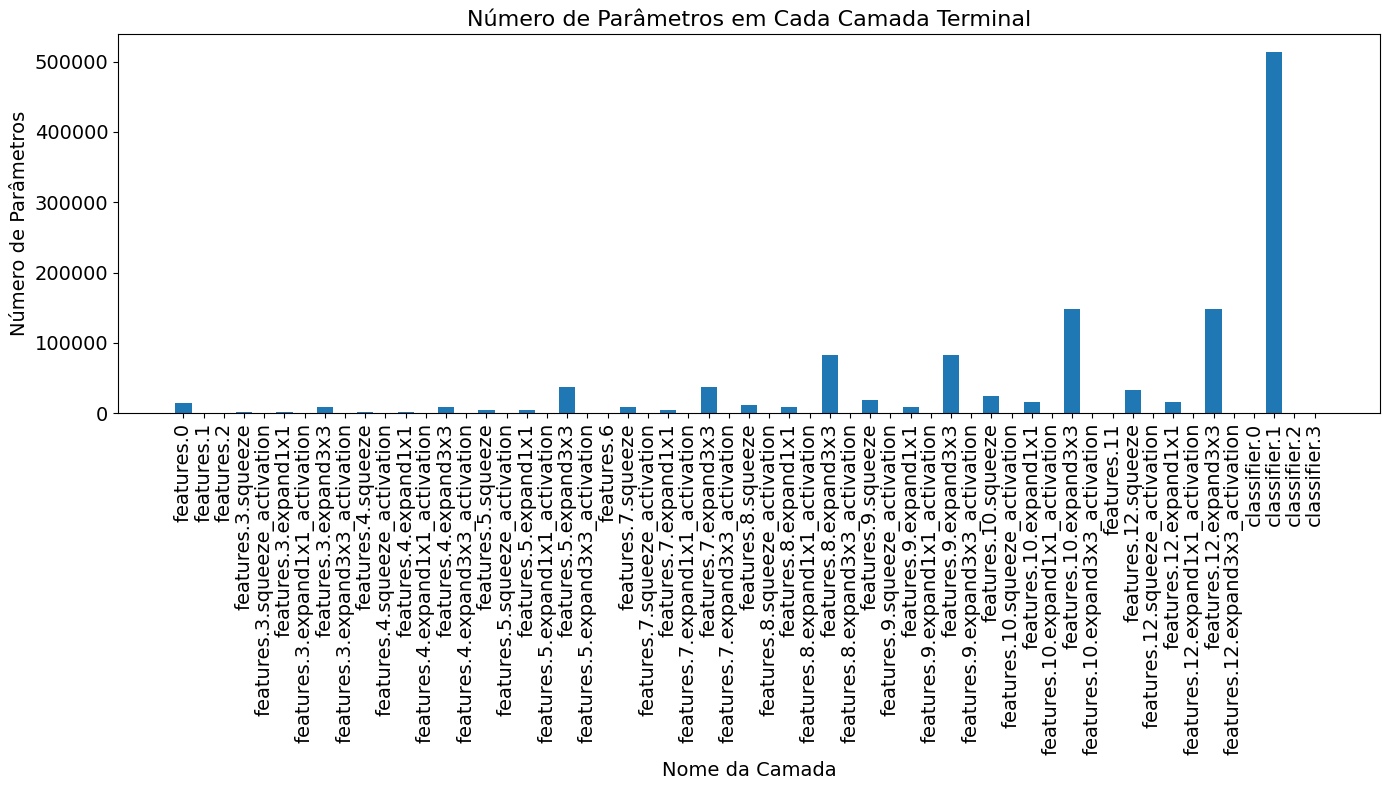

In [21]:
# Inicializa um dicionário vazio para armazenar a contagem de parâmetros por camada
counting_params = {}

# Itera por todos os módulos nomeados da rede e imprime a quantidade de parâmetros de cada camada terminal
for layer in complex_model.named_modules():
    # Obtém o número de subcamadas/filhos da camada atual
    # layer[0] contém o nome da camada e layer[1] contém o objeto da camada
    n_children = len(list(layer[1].children()))
    
    # Se não houver subcamadas filhas, significa que chegamos a uma camada terminal
    if n_children == 0:  
        layer_name = layer[0]
        # Soma o número total de elementos (numel) de todos os tensores de parâmetros desta camada
        n_parameters = sum(p.numel() for p in layer[1].parameters())
        # Armazena o resultado no dicionário usando o nome da camada como chave
        counting_params[layer_name] = n_parameters
        
        # Exibe a contagem formatada no console
        print(f"A Camada '{layer_name}' possui {n_parameters} parâmetros")

# Gera o gráfico de distribuição de parâmetros por camada usando a função utilitária
helper_utils_8.plot_counting(counting_params)

# Conclusão

Você agora depurou, refatorou e inspecionou modelos PyTorch com sucesso.
Neste laboratório, você viu em primeira mão que a passagem direta (*forward pass*) de um modelo não é uma caixa preta e que, adicionando estrategicamente instruções de impressão (*print statements*), você pode diagnosticar e resolver erros comuns, mas frustrantes, como incompatibilidades de formato (*shape mismatches*).

Você foi além de simplesmente escrever o código do modelo e agora pode torná-lo mais robusto e legível agrupando camadas em blocos lógicos com o **`nn.Sequential`**.
Essa prática de modularização torna as suas arquiteturas mais fáceis de entender, reutilizar e adaptar.
Você também aprendeu a realizar verificações de sanidade (*sanity checks*) essenciais inspecionando as estatísticas de ativação e a explorar sistematicamente qualquer modelo PyTorch, por mais complexo que seja, usando utilitários de inspeção como `.modules()` e `.named_children()`.

Com essas habilidades fundamentais de depuração e inspeção, você está bem preparado para desafios mais avançados.